# EDA — Brasileirão Série A (2022–2024)

In [1]:
import os
from pathlib import Path

here = Path.cwd()
project_root = next(p for p in [here, *here.parents] if (p / "pyproject.toml").exists())
os.chdir(project_root)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from chute_certo.ingestion.processing import load_seasons

sns.set_theme(style="whitegrid")

df = load_seasons([2022, 2023, 2024])
date_range = f"{df['date'].min().date()} → {df['date'].max().date()}"
print(f"{len(df)} jogos | {df['season'].nunique()} temporadas | {date_range}")
df.head()

2026-05-20 21:21:00.984 | INFO     | chute_certo.ingestion.processing:parse_fixtures:54 - Parsed 380 finished fixtures
2026-05-20 21:21:00.999 | INFO     | chute_certo.ingestion.processing:parse_fixtures:54 - Parsed 380 finished fixtures
2026-05-20 21:21:01.018 | INFO     | chute_certo.ingestion.processing:parse_fixtures:54 - Parsed 380 finished fixtures
2026-05-20 21:21:01.022 | INFO     | chute_certo.ingestion.processing:load_seasons:75 - Loaded 1140 total fixtures across 3 season(s)


1140 jogos | 3 temporadas | 2022-04-09 → 2024-12-08


,fixture_id,date,season,round,home_team_id,home_team,away_team_id,away_team,home_goals,away_goals,ht_home_goals,ht_away_goals,venue,referee,result
0,837992,2022-04-09 19:30:00+00:00,2022,1,124,Fluminense,128,Santos,0,0,0,0,Estadio Jornalista Mário Filho,Anderson Daronco,D
1,837998,2022-04-09 22:00:00+00:00,2022,1,144,Atletico Goianiense,127,Flamengo,1,1,0,0,Estádio Antônio Accioly,Braulio da Silva Machado,D
2,837994,2022-04-10 00:00:00+00:00,2022,1,121,Palmeiras,129,Ceara,2,3,1,2,Allianz Parque,Caio Max Augusto Vieira,A
3,838000,2022-04-10 14:00:00+00:00,2022,1,147,Coritiba,151,Goias,3,0,1,0,Estádio Major Antônio Couto Pereira,Raphael Claus,H
4,837995,2022-04-10 19:00:00+00:00,2022,1,120,Botafogo,131,Corinthians,1,3,0,3,Estádio Nilton Santos,Wilton Pereira Sampaio,A


## Distribuição dos resultados

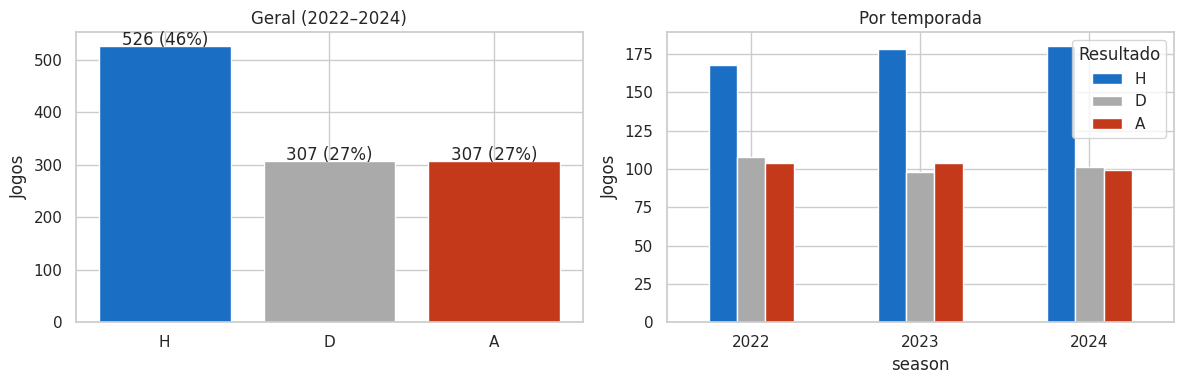

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# geral
counts = df["result"].value_counts().reindex(["H", "D", "A"])
axes[0].bar(counts.index, counts.values, color=["#1a6fc4", "#aaaaaa", "#c4391a"])
axes[0].set_title("Geral (2022–2024)")
axes[0].set_ylabel("Jogos")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, f"{v} ({v / len(df):.0%})", ha="center")

# por temporada
by_season = (
    df.groupby(["season", "result"]).size().unstack().reindex(columns=["H", "D", "A"])
)
by_season.plot(kind="bar", ax=axes[1], color=["#1a6fc4", "#aaaaaa", "#c4391a"], rot=0)
axes[1].set_title("Por temporada")
axes[1].set_ylabel("Jogos")
axes[1].legend(title="Resultado")

plt.tight_layout()
plt.show()

## Gols

In [4]:
df["total_goals"] = df["home_goals"] + df["away_goals"]

print(f"Média de gols por jogo: {df['total_goals'].mean():.2f}")
print(f"Média mandante:   {df['home_goals'].mean():.2f}")
print(f"Média visitante:  {df['away_goals'].mean():.2f}")
print()
print(df["total_goals"].value_counts().sort_index().to_string())

Média de gols por jogo: 2.44
Média mandante:   1.41
Média visitante:  1.03

total_goals
0      82
1     251
2     291
3     280
4     136
5      60
6      25
7       9
8       5
10      1


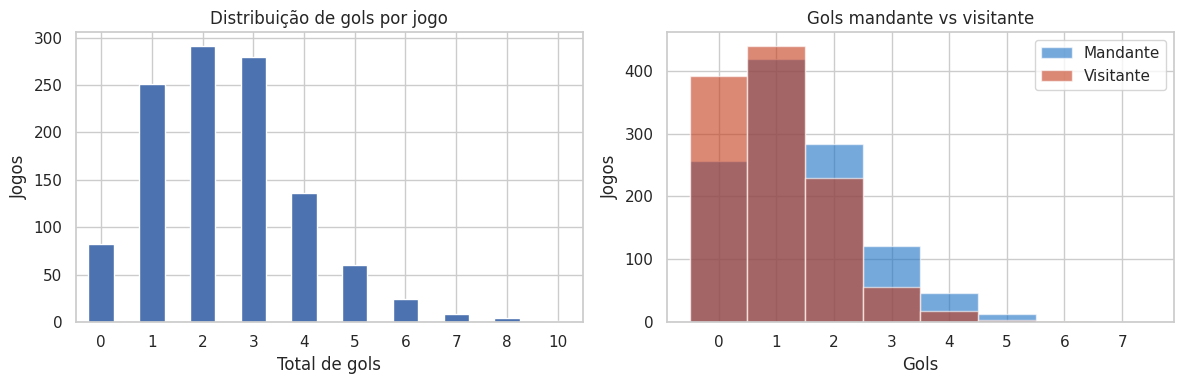

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["total_goals"].value_counts().sort_index().plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Distribuição de gols por jogo")
axes[0].set_xlabel("Total de gols")
axes[0].set_ylabel("Jogos")

axes[1].hist(
    df["home_goals"],
    bins=range(0, 9),
    alpha=0.6,
    label="Mandante",
    color="#1a6fc4",
    align="left",
)
axes[1].hist(
    df["away_goals"],
    bins=range(0, 9),
    alpha=0.6,
    label="Visitante",
    color="#c4391a",
    align="left",
)
axes[1].set_title("Gols mandante vs visitante")
axes[1].set_xlabel("Gols")
axes[1].set_ylabel("Jogos")
axes[1].legend()

plt.tight_layout()
plt.show()

## Vantagem de mandante por rodada

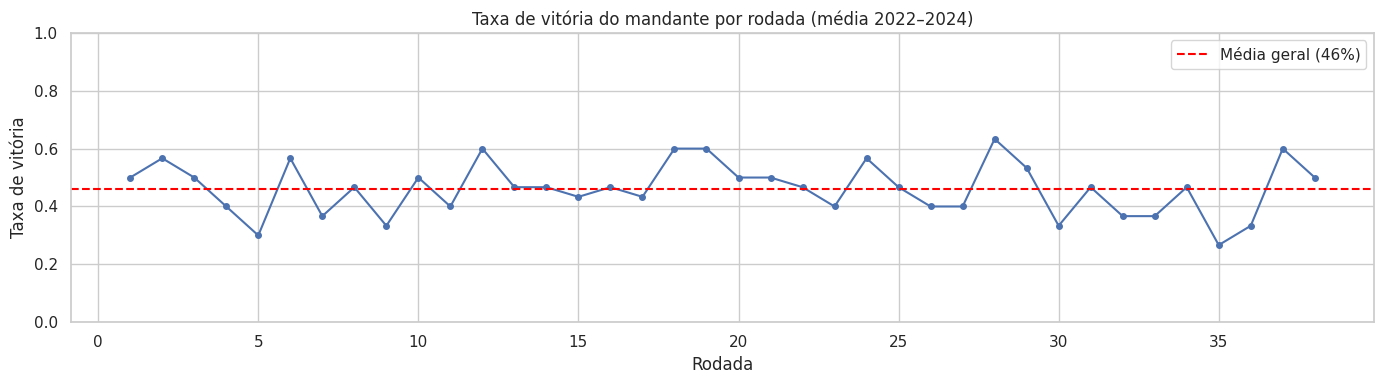

In [6]:
home_win_rate = (
    df.groupby("round")["result"]
    .apply(lambda x: (x == "H").mean())
    .reset_index(name="home_win_rate")
)

plt.figure(figsize=(14, 4))
plt.plot(
    home_win_rate["round"], home_win_rate["home_win_rate"], marker="o", markersize=4
)
plt.axhline(
    df["result"].eq("H").mean(),
    color="red",
    linestyle="--",
    label=f"Média geral ({df['result'].eq('H').mean():.0%})",
)
plt.title("Taxa de vitória do mandante por rodada (média 2022–2024)")
plt.xlabel("Rodada")
plt.ylabel("Taxa de vitória")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## Placares mais frequentes

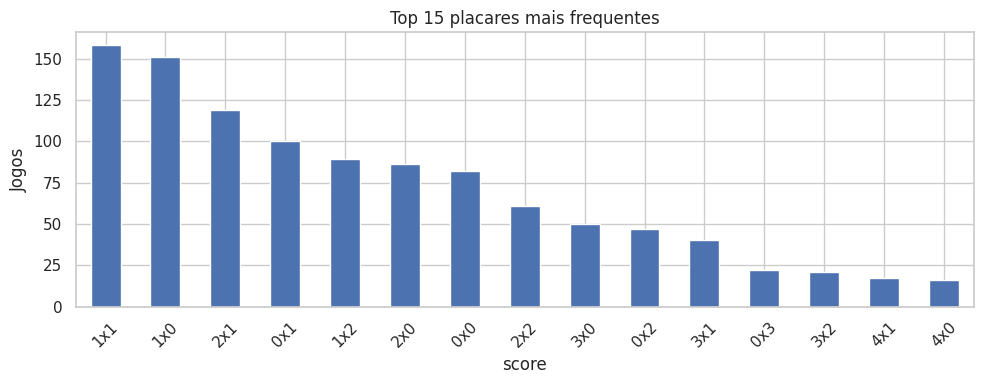

In [7]:
df["score"] = df["home_goals"].astype(str) + "x" + df["away_goals"].astype(str)
top_scores = df["score"].value_counts().head(15)

plt.figure(figsize=(10, 4))
top_scores.plot(kind="bar", rot=45)
plt.title("Top 15 placares mais frequentes")
plt.ylabel("Jogos")
plt.tight_layout()
plt.show()

## Times com mais vitórias em casa e fora

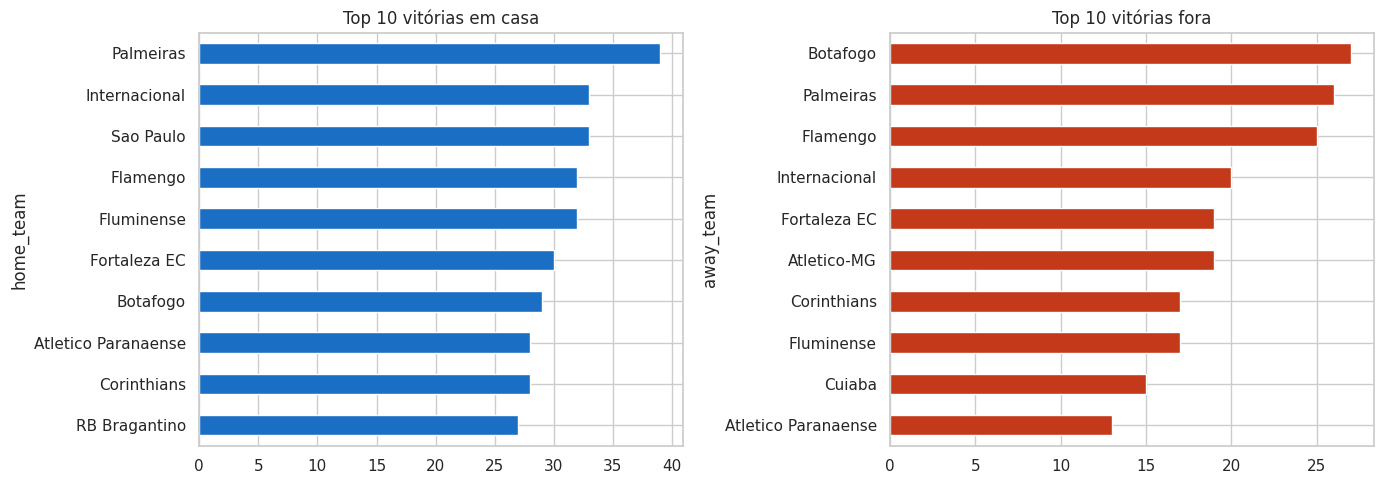

In [8]:
home_wins = (
    df[df["result"] == "H"]
    .groupby("home_team")
    .size()
    .sort_values(ascending=False)
    .head(10)
)
away_wins = (
    df[df["result"] == "A"]
    .groupby("away_team")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

home_wins.plot(kind="barh", ax=axes[0], color="#1a6fc4")
axes[0].set_title("Top 10 vitórias em casa")
axes[0].invert_yaxis()

away_wins.plot(kind="barh", ax=axes[1], color="#c4391a")
axes[1].set_title("Top 10 vitórias fora")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()